# Supplementary Figure in Gaia J1644-0449 paper that is the total age histograms all stacked on the same set of axes

Basically, I want to make a three-panel plot of the associated MC distributions of Gaia J1644-0449, SDSS J1330+6435, and WD J2356-209, which shows the result of all of the transformations that the original mass and temperature distribution have to go through.

So I need to do all of the imports that I usually do I suppose.

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
import matplotlib.patches as mp

#start = time.time()


import spec_plot_tools as spt
import cal_params as cp
#import plot_spec as ps
#import bensby_plotting as bp
print(os.getcwd())

/Users/BenKaiser/Desktop/radial_velocity_calculations


In [2]:
target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/'
os.chdir(target_dir)

In [3]:
J1644_file='GaiaJ1644m0449_tot_age_MC.csv'
J1330_file='SDSSJ1330p6435_tot_age_MC.csv'
J2356_file='WDJ2356m209_tot_age_MC.csv'
wd_abund_file='temp_wd_abundances.csv'

In [4]:
color_dict={
    'GaiaJ1644-0449':'r',
    'SDSSJ1330+6435':'darkviolet',
    'WDJ2356-209':'g'
}
step_dict={
    'GaiaJ1644-0449':10,
    'SDSSJ1330+6435':0.1,
    'WDJ2356-209':10
}

wd_marker='*'
met_marker='D'
met_color='#1ca1f2'
ci_size=14
ci_leg_size=10
wd_size=14
dp_alpha=1
arr_naca=[-0.4,-0.1]

star_marker='o'
pop_colors=['darkorange','brown','navy','grey'] #thin disk, thick disk, halo, in-between for Bensby plots




Below are the values to construct the error bar datapoints as used in the [Li/Ca] vs. Age plot.

And then loading those should just be a simple numpy.genfromtxt() because it's a 1-D array... or at least it was when I saved it in the other script...

In [5]:
J1644_mc= np.genfromtxt(J1644_file)
J1330_mc= np.genfromtxt(J1330_file)
J2356_mc= np.genfromtxt(J2356_file)

In [6]:
wd_abund_table=Table.read(wd_abund_file)
wd_abund_table.add_index('name')

In [7]:
print(J1644_mc.shape)
print(J1330_mc.shape)

(146551,)
(917401,)


Yeah that shape looks about right, and the J1330 shape exactly matches the print statement in the Terminal. I only checked that one explicitly because it was the last one I ran, so it was right there. I really doubt the shape is messed up anywhere therefore.

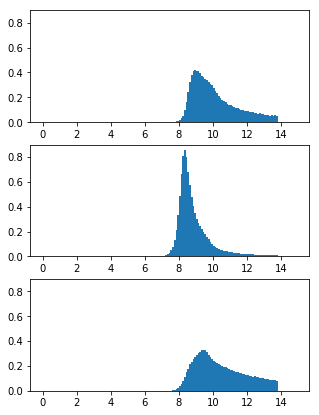

In [8]:
bins=np.arange(0,15,0.1)
plt.figure(figsize=(5,7))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True)
plt.subplot(3,1,2, sharex=ax3, sharey=ax3)
plt.hist(J1330_mc, bins=bins, normed=True)
plt.subplot(3,1,1, sharex=ax3, sharey=ax3)
plt.hist(J1644_mc, bins=bins, normed=True)
#plt.text(0,0,'J1644')
plt.show()

Hmmm... So that appears to have "shared" the axes in that they are all forced to match, but I want them to literally share axes so that there aren't additional labels (and white space) on the upper two plots. To the internet further!

In [9]:
import matplotlib
print(matplotlib.__version__)

2.0.0


I needed that because apparently the 3.1.2 version tricks aren't working for me. So damn. Ok it would seem that one has to actually initialize the plots using plt.subplots() instead of plt.subplot()... well that's tedious

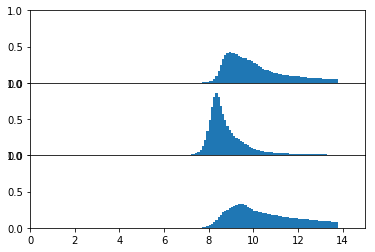

In [10]:
bins=np.arange(0,15,0.1)
#plt.figure(figsize=(5,7))
fig, axes= plt.subplots(3,1,sharex=True,sharey=True)
axes[2].hist(J2356_mc, bins=bins,normed=True)
#plt.subplot(3,1,2, sharex=True, sharey=ax3)
axes[1].hist(J1330_mc, bins=bins, normed=True)
#plt.subplot(3,1,1, sharex=True, sharey=ax3)
axes[0].hist(J1644_mc, bins=bins, normed=True)
plt.subplots_adjust(hspace=0)
plt.xlim(0,15)
plt.ylim(0,1)

#plt.text(0,0,'J1644')
plt.show()

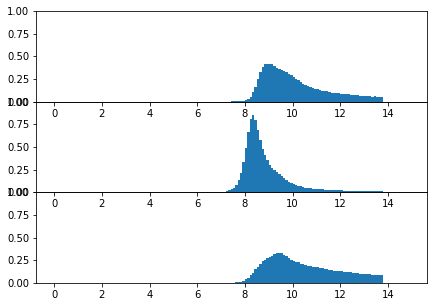

In [11]:
bins=np.arange(0,15,0.1)
plt.figure(figsize=(7,5))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True)
ax2=plt.subplot(3,1,2, sharex=ax3, sharey=ax3)
plt.hist(J1330_mc, bins=bins, normed=True)
ax1=plt.subplot(3,1,1, sharex=ax3, sharey=ax3)
plt.hist(J1644_mc, bins=bins, normed=True)
#ax1.set_xticklabels([])
plt.subplots_adjust(hspace=0)

plt.ylim(0,1)
#plt.text(0,0,'J1644')
plt.show()

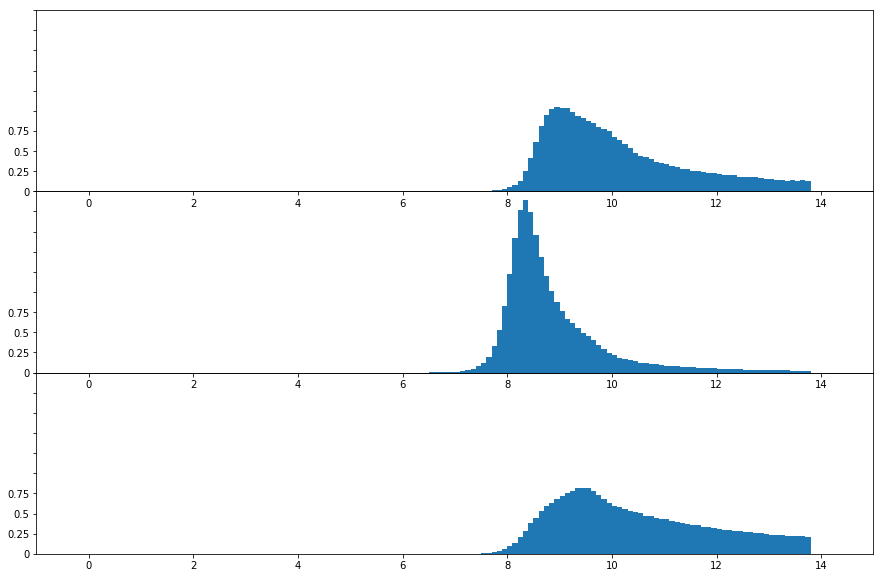

In [12]:
bins=np.arange(0,15,0.1)
plt.figure(figsize=(15,10))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True)
ax2=plt.subplot(3,1,2, sharey=ax3,sharex=ax3)
plt.hist(J1330_mc, bins=bins, normed=True)
ax1=plt.subplot(3,1,1, sharey=ax3,sharex=ax3)
plt.hist(J1644_mc, bins=bins, normed=True)
#ax1.set_xticklabels([])
plt.subplots_adjust(hspace=0)
ax3.set_yticklabels([0,0.25,0.5,0.75])
plt.xlim(-1,15)
#plt.text(0,0,'J1644')
#plt.ylim(0,0.75)
plt.show()

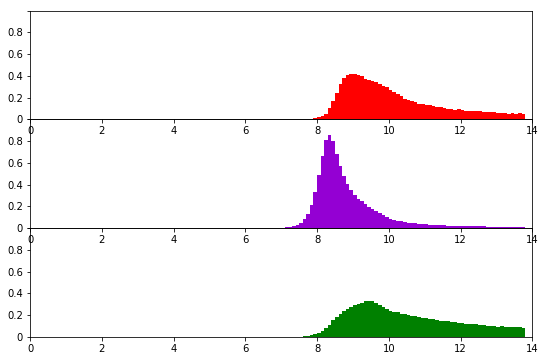

In [13]:
bins=np.arange(0,15,0.1)
plt.figure(figsize=(9,6))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True, color=color_dict['WDJ2356-209'])
ax2=plt.subplot(3,1,2, sharey=ax3,sharex=ax3)
plt.hist(J1330_mc, bins=bins, normed=True, color=color_dict['SDSSJ1330+6435'])
ax1=plt.subplot(3,1,1, sharey=ax3,sharex=ax3)
plt.hist(J1644_mc, bins=bins, normed=True, color=color_dict['GaiaJ1644-0449'])
#ax1.set_xticklabels([])
ax1.set_yticklabels([0,0.2,0.4,0.6,0.8,])
plt.subplots_adjust(hspace=0)
plt.xlim(0,14)
#plt.text(0,0,'J1644')
plt.ylim(0,1)
plt.show()

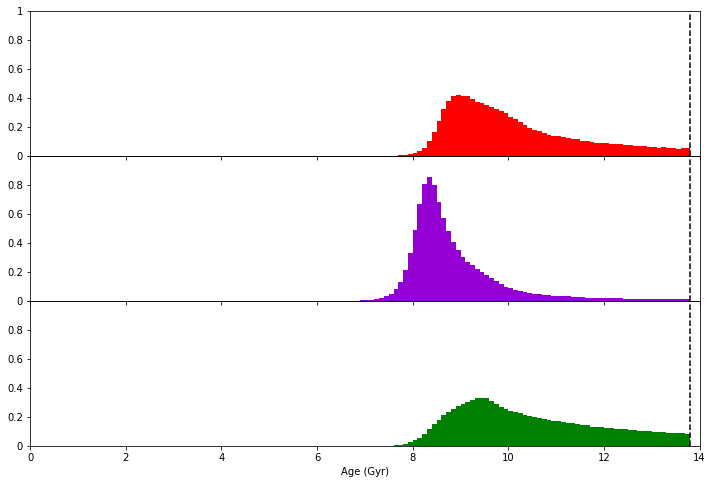

In [14]:
bins=np.arange(0,15,0.1)
plt.figure(figsize=(12,8))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True, color=color_dict['WDJ2356-209'])
plt.xlabel('Age (Gyr)')
plt.axvline(13.8, color='k',linestyle='--')
ax2=plt.subplot(3,1,2, sharey=ax3)
plt.hist(J1330_mc, bins=bins, normed=True, color=color_dict['SDSSJ1330+6435'])
plt.axvline(13.8, color='k',linestyle='--')
ax1=plt.subplot(3,1,1)
plt.hist(J1644_mc, bins=bins, normed=True, color=color_dict['GaiaJ1644-0449'])
plt.axvline(13.8, color='k',linestyle='--')
#ax1.set_xticklabels([])
ax1.get_shared_x_axes().join(ax1,ax3)
ax2.get_shared_x_axes().join(ax2,ax3)
ax1.set_xticklabels([])
ax2.set_xticklabels([])
ax2.set_yticklabels([0,0.2,0.4,0.6,0.8,])
ax1.get_shared_y_axes().join(ax1,ax3)
ax1.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
plt.subplots_adjust(hspace=0)
plt.xlim(0,14)
#plt.text(0,0,'J1644')
plt.ylim(0,1)
plt.show()

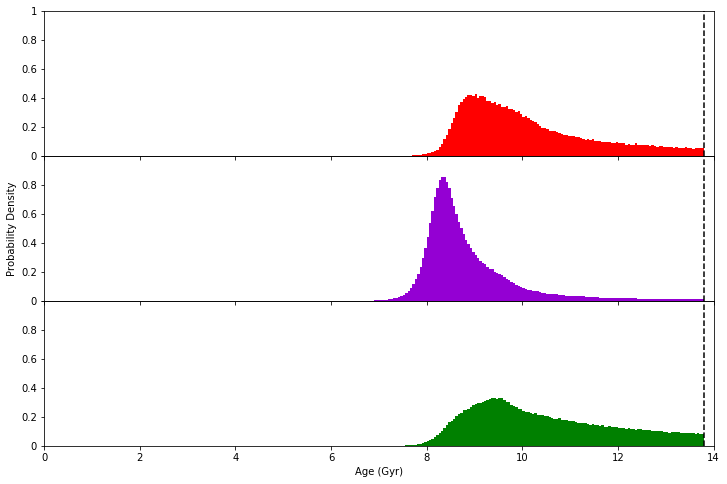

In [15]:
bins=np.arange(0,15,0.05)
plt.figure(figsize=(12,8))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True, color=color_dict['WDJ2356-209'])
plt.xlabel('Age (Gyr)')
plt.axvline(13.8, color='k',linestyle='--')
ax2=plt.subplot(3,1,2, sharey=ax3)
plt.hist(J1330_mc, bins=bins, normed=True, color=color_dict['SDSSJ1330+6435'])
plt.ylabel('Probability Density')
plt.axvline(13.8, color='k',linestyle='--')
ax1=plt.subplot(3,1,1)
plt.hist(J1644_mc, bins=bins, normed=True, color=color_dict['GaiaJ1644-0449'])
plt.axvline(13.8, color='k',linestyle='--')
#ax1.set_xticklabels([])
ax1.get_shared_x_axes().join(ax1,ax3)
ax2.get_shared_x_axes().join(ax2,ax3)
ax1.set_xticklabels([])
ax2.set_xticklabels([])
ax2.set_yticklabels([0,0.2,0.4,0.6,0.8,])
ax1.get_shared_y_axes().join(ax1,ax3)
ax1.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
plt.subplots_adjust(hspace=0)
plt.xlim(0,14)
#plt.text(0,0,'J1644')
plt.ylim(0,1)
plt.show()

____________________________

## ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
## The real deal figure is below here

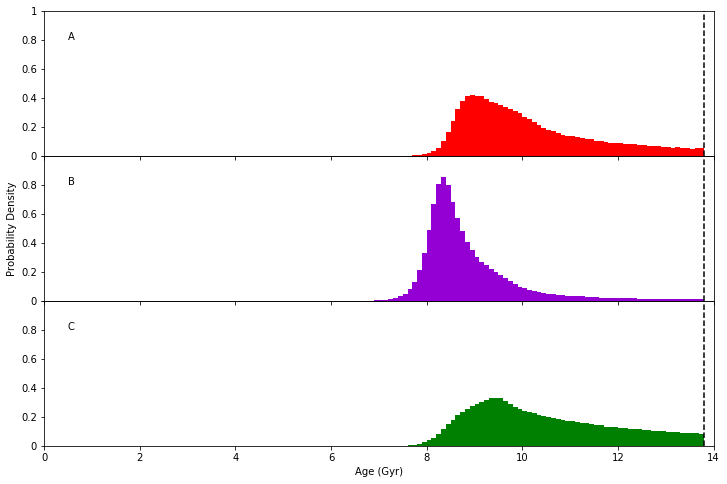

In [16]:
text_pos= [0.5,0.8]

bins=np.arange(0,15,0.1)
plt.figure(figsize=(12,8))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True, color=color_dict['WDJ2356-209'])
plt.xlabel('Age (Gyr)')
plt.text(text_pos[0],text_pos[1],'C')
plt.axvline(13.8, color='k',linestyle='--')
ax2=plt.subplot(3,1,2, sharey=ax3)
plt.hist(J1330_mc, bins=bins, normed=True, color=color_dict['SDSSJ1330+6435'])
plt.text(text_pos[0],text_pos[1],'B')
plt.ylabel('Probability Density')
plt.axvline(13.8, color='k',linestyle='--')
ax1=plt.subplot(3,1,1)
plt.hist(J1644_mc, bins=bins, normed=True, color=color_dict['GaiaJ1644-0449'])
plt.text(text_pos[0],text_pos[1],'A')
plt.axvline(13.8, color='k',linestyle='--')
#ax1.set_xticklabels([])
ax1.get_shared_x_axes().join(ax1,ax3)
ax2.get_shared_x_axes().join(ax2,ax3)
ax1.set_xticklabels([])
ax2.set_xticklabels([])
ax2.set_yticklabels([0,0.2,0.4,0.6,0.8,])
ax1.get_shared_y_axes().join(ax1,ax3)
ax1.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
plt.subplots_adjust(hspace=0)
plt.xlim(0,14)
#plt.text(0,0,'J1644')
plt.ylim(0,1)
plt.show()

#### Alternatively, we could label the panels with the actual names of the white dwarfs... that would seem to be the more logical move

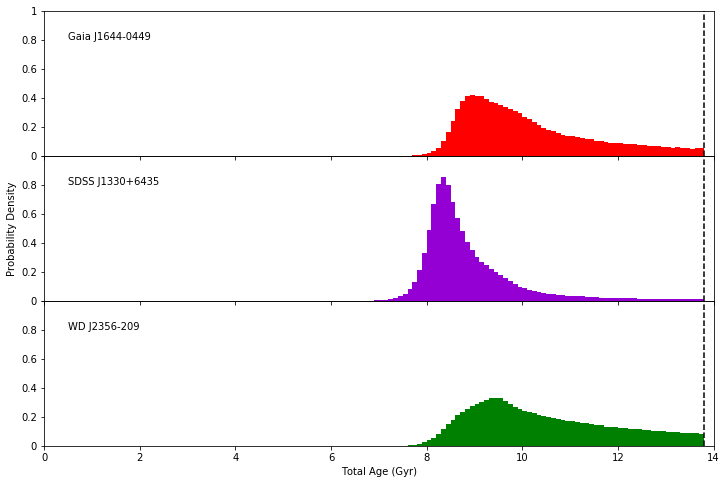

In [20]:
text_pos= [0.5,0.8]

bins=np.arange(0,15,0.1)
plt.figure(figsize=(12,8))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True, color=color_dict['WDJ2356-209'])
plt.xlabel('Total Age (Gyr)')
#plt.text(text_pos[0],text_pos[1],'C')
plt.text(text_pos[0],text_pos[1],'WD J2356-209')
plt.axvline(13.8, color='k',linestyle='--')
ax2=plt.subplot(3,1,2, sharey=ax3)
plt.hist(J1330_mc, bins=bins, normed=True, color=color_dict['SDSSJ1330+6435'])
#plt.text(text_pos[0],text_pos[1],'B')
plt.text(text_pos[0],text_pos[1],'SDSS J1330+6435')

plt.ylabel('Probability Density')
plt.axvline(13.8, color='k',linestyle='--')
ax1=plt.subplot(3,1,1)
plt.hist(J1644_mc, bins=bins, normed=True, color=color_dict['GaiaJ1644-0449'])
#plt.text(text_pos[0],text_pos[1],'A')
plt.text(text_pos[0],text_pos[1],'Gaia J1644-0449')

plt.axvline(13.8, color='k',linestyle='--')
#ax1.set_xticklabels([])
ax1.get_shared_x_axes().join(ax1,ax3)
ax2.get_shared_x_axes().join(ax2,ax3)
ax1.set_xticklabels([])
ax2.set_xticklabels([])
ax2.set_yticklabels([0,0.2,0.4,0.6,0.8,])
ax1.get_shared_y_axes().join(ax1,ax3)
ax1.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
plt.subplots_adjust(hspace=0)
plt.xlim(0,14)
#plt.text(0,0,'J1644')
plt.ylim(0,1)
plt.show()

I kind of want to see the median and 68% interquartile range now...

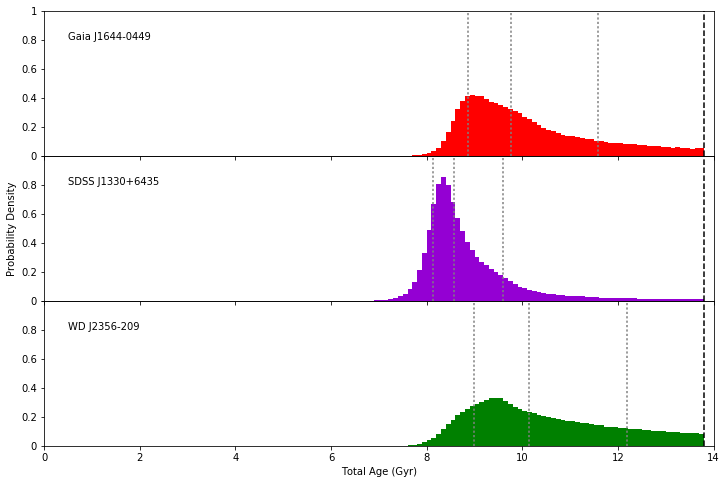

In [21]:
text_pos= [0.5,0.8]
perc_steps=[16,50,84]
bins=np.arange(0,15,0.1)
plt.figure(figsize=(12,8))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True, color=color_dict['WDJ2356-209'])
for perc in perc_steps:
    plt.axvline(x=np.percentile(J2356_mc,perc), color='grey',linestyle=':')
plt.xlabel('Total Age (Gyr)')
#plt.text(text_pos[0],text_pos[1],'C')
plt.text(text_pos[0],text_pos[1],'WD J2356-209')
plt.axvline(13.8, color='k',linestyle='--')
ax2=plt.subplot(3,1,2, sharey=ax3)
plt.hist(J1330_mc, bins=bins, normed=True, color=color_dict['SDSSJ1330+6435'])
for perc in perc_steps:
    plt.axvline(x=np.percentile(J1330_mc,perc), color='grey',linestyle=':')
#plt.text(text_pos[0],text_pos[1],'B')
plt.text(text_pos[0],text_pos[1],'SDSS J1330+6435')

plt.ylabel('Probability Density')
plt.axvline(13.8, color='k',linestyle='--')
ax1=plt.subplot(3,1,1)
plt.hist(J1644_mc, bins=bins, normed=True, color=color_dict['GaiaJ1644-0449'])
for perc in perc_steps:
    plt.axvline(x=np.percentile(J1644_mc,perc), color='grey',linestyle=':')
#plt.text(text_pos[0],text_pos[1],'A')
plt.text(text_pos[0],text_pos[1],'Gaia J1644-0449')

plt.axvline(13.8, color='k',linestyle='--')
#ax1.set_xticklabels([])
ax1.get_shared_x_axes().join(ax1,ax3)
ax2.get_shared_x_axes().join(ax2,ax3)
ax1.set_xticklabels([])
ax2.set_xticklabels([])
ax2.set_yticklabels([0,0.2,0.4,0.6,0.8,])
ax1.get_shared_y_axes().join(ax1,ax3)
ax1.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
plt.subplots_adjust(hspace=0)
plt.xlim(0,14)
#plt.text(0,0,'J1644')
plt.ylim(0,1)
plt.show()

I think I want to see that though with the M/L point and minimized width 68% confidence interval.

In [22]:
def plot_ml(row, ypos=0.95):
    age_errs= [[row['age_minus']],[row['age_plus']]]
    plt.errorbar(float(row['age']),ypos,xerr=age_errs,label=row['name'],marker=wd_marker, color=color_dict[row['name']],markersize=wd_size, linestyle='None')
    return

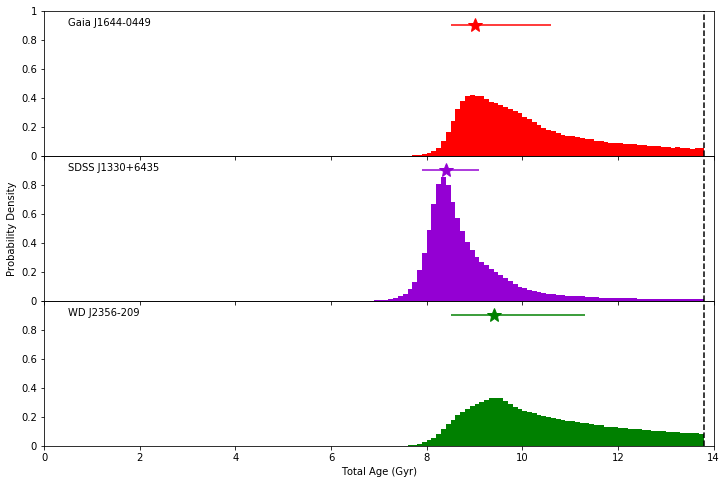

In [35]:
ypos=0.9
#text_pos= [0.5,0.8]
text_pos=[0.5,ypos]
perc_steps=[16,50,84]
bins=np.arange(0,15,0.1)
#bins=np.arange(0,15,0.01)
plt.figure(figsize=(12,8))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True, color=color_dict['WDJ2356-209'])
#for perc in perc_steps:
#    plt.axvline(x=np.percentile(J2356_mc,perc), color='grey',linestyle=':')
plot_ml(wd_abund_table.loc['WDJ2356-209'], ypos=ypos)
plt.xlabel('Total Age (Gyr)')
#plt.text(text_pos[0],text_pos[1],'C')
plt.text(text_pos[0],text_pos[1],'WD J2356-209')
plt.axvline(13.8, color='k',linestyle='--')
ax2=plt.subplot(3,1,2, sharey=ax3)
plt.hist(J1330_mc, bins=bins, normed=True, color=color_dict['SDSSJ1330+6435'])
#for perc in perc_steps:
#    plt.axvline(x=np.percentile(J1330_mc,perc), color='grey',linestyle=':')
plot_ml(wd_abund_table.loc['SDSSJ1330+6435'], ypos=ypos)
#plt.text(text_pos[0],text_pos[1],'B')
plt.text(text_pos[0],text_pos[1],'SDSS J1330+6435')

plt.ylabel('Probability Density')
plt.axvline(13.8, color='k',linestyle='--')
ax1=plt.subplot(3,1,1)
plt.hist(J1644_mc, bins=bins, normed=True, color=color_dict['GaiaJ1644-0449'])
#for perc in perc_steps:
#    plt.axvline(x=np.percentile(J1644_mc,perc), color='grey',linestyle=':')
plot_ml(wd_abund_table.loc['GaiaJ1644-0449'],ypos=ypos)
#plt.text(text_pos[0],text_pos[1],'A')
plt.text(text_pos[0],text_pos[1],'Gaia J1644-0449')

plt.axvline(13.8, color='k',linestyle='--')
#ax1.set_xticklabels([])
ax1.get_shared_x_axes().join(ax1,ax3)
ax2.get_shared_x_axes().join(ax2,ax3)
ax1.set_xticklabels([])
ax2.set_xticklabels([])
ax2.set_yticklabels([0,0.2,0.4,0.6,0.8,])
ax1.get_shared_y_axes().join(ax1,ax3)
ax1.set_yticklabels([0,0.2,0.4,0.6,0.8,1])
plt.subplots_adjust(hspace=0)
plt.xlim(0,14)
#plt.xlim(6,10)
#plt.text(0,0,'J1644')
plt.ylim(0,1)
plt.show()

What are the minimum ages in those ranges by the way?

In [19]:
print(np.min(J1644_mc))
print(np.min(J1330_mc))
print(np.min(J2356_mc))

6.48415539806
5.52689705226
7.03054847492


So it would appear that 5.5 would be a pretty safe hypothetical lower value.

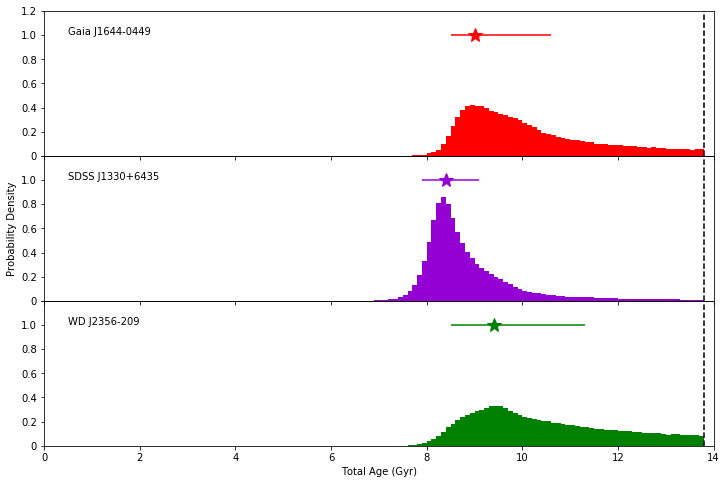

In [40]:
ypos=1
#text_pos= [0.5,0.8]
text_pos=[0.5,ypos]
perc_steps=[16,50,84]
bins=np.arange(0,15,0.1)
#bins=np.arange(0,15,0.01)
plt.figure(figsize=(12,8))
ax3=plt.subplot(3,1,3)
plt.hist(J2356_mc, bins=bins,normed=True, color=color_dict['WDJ2356-209'])
#for perc in perc_steps:
#    plt.axvline(x=np.percentile(J2356_mc,perc), color='grey',linestyle=':')
plot_ml(wd_abund_table.loc['WDJ2356-209'], ypos=ypos)
plt.xlabel('Total Age (Gyr)')
#plt.text(text_pos[0],text_pos[1],'C')
plt.text(text_pos[0],text_pos[1],'WD J2356-209')
plt.axvline(13.8, color='k',linestyle='--')
ax2=plt.subplot(3,1,2, sharey=ax3)
plt.hist(J1330_mc, bins=bins, normed=True, color=color_dict['SDSSJ1330+6435'])
#for perc in perc_steps:
#    plt.axvline(x=np.percentile(J1330_mc,perc), color='grey',linestyle=':')
plot_ml(wd_abund_table.loc['SDSSJ1330+6435'], ypos=ypos)
#plt.text(text_pos[0],text_pos[1],'B')
plt.text(text_pos[0],text_pos[1],'SDSS J1330+6435')

plt.ylabel('Probability Density')
plt.axvline(13.8, color='k',linestyle='--')
ax1=plt.subplot(3,1,1)
plt.hist(J1644_mc, bins=bins, normed=True, color=color_dict['GaiaJ1644-0449'])
#for perc in perc_steps:
#    plt.axvline(x=np.percentile(J1644_mc,perc), color='grey',linestyle=':')
plot_ml(wd_abund_table.loc['GaiaJ1644-0449'],ypos=ypos)
#plt.text(text_pos[0],text_pos[1],'A')
plt.text(text_pos[0],text_pos[1],'Gaia J1644-0449')

plt.axvline(13.8, color='k',linestyle='--')
#ax1.set_xticklabels([])
ax1.get_shared_x_axes().join(ax1,ax3)
ax2.get_shared_x_axes().join(ax2,ax3)
ax1.set_xticklabels([])
ax2.set_xticklabels([])
ax2.set_yticklabels([0,0.2,0.4,0.6,0.8,1.0])
ax1.get_shared_y_axes().join(ax1,ax3)
ax1.set_yticklabels([0,0.2,0.4,0.6,0.8,1.0,1.2])
plt.subplots_adjust(hspace=0)
plt.xlim(0,14)
#plt.xlim(6,10)
#plt.text(0,0,'J1644')
plt.ylim(0,1.2)
plt.show()